# Celltype decomposition with Bisque
https://www.nature.com/articles/s41467-020-15816-6

In [1]:
suppressPackageStartupMessages({
    library(BisqueRNA)
    library(ggplot2)
    library(tidyr)
    library(purrr)
    library(data.table)
    library(Seurat)
})

Warning message:
“package ‘Seurat’ was built under R version 4.1.2”


In [2]:
celltype_colours = c("Epiblast" = "#635547",
                     "Primitive Streak" = "#DABE99",
                     "Caudal epiblast" = "#9e6762",
                     
                     "PGC" = "#FACB12",
                     
                     "Anterior Primitive Streak" = "#c19f70",
                     "Notochord" = "#0F4A9C",
                     "Def. endoderm" = "#F397C0",
                     "Gut" = "#EF5A9D",
                     
                     "Nascent mesoderm" = "#C594BF",
                     "Mixed mesoderm" = "#DFCDE4",
                     "Intermediate mesoderm" = "#139992",
                     "Caudal Mesoderm" = "#3F84AA",
                     "Paraxial mesoderm" = "#8DB5CE",
                     "Somitic mesoderm" = "#005579",
                     "Pharyngeal mesoderm" = "#C9EBFB",
                     "Cardiomyocytes" = "#B51D8D",
                     "Allantois" = "#532C8A",
                     "ExE mesoderm" = "#8870ad",
                     "Mesenchyme" = "#cc7818",
                     
                     "Haematoendothelial progenitors" = "#FBBE92",
                     "Endothelium" = "#ff891c",
                     "Blood progenitors 1" = "#f9decf",
                     "Blood progenitors 2" = "#c9a997",
                     "Erythroid1" = "#C72228",
                     "Erythroid2" = "#f79083",
                     "Erythroid3" = "#EF4E22",
                     
                     "NMP" = "#8EC792",
                     
                     "Rostral neurectoderm" = "#65A83E",
                     "Caudal neurectoderm" = "#354E23",
                     "Neural crest" = "#C3C388",
                     "Forebrain/Midbrain/Hindbrain" = "#647a4f",
                     "Spinal cord" = "#CDE088",
                     
                     "Surface ectoderm" = "#f7f79e",
                     
                     "Visceral endoderm" = "#F6BFCB",
                     "ExE endoderm" = "#7F6874",
                     "ExE ectoderm" = "#989898",
                     "Parietal endoderm" = "#1A1A1A")

In [12]:
# Load bulk data 
countData <- as.matrix(read.csv('gene_count_matrix_epiblast.csv', row.names = 'gene_id'))
rownames(countData) = rownames(countData) %>% strsplit('[|]') %>% map(2) # change rownames

colData <- read.csv('phenodata_epi2.csv', row.names = 1)
colData$genotype = gsub("-/-", "null", colData$genotype)
colData$group = paste0(colData$genotype, '_',colData$stage)

#E5.5, E6.5, E7.5
##Remove ex5.5 results
#select E7.5 data
colE567 <- colData[colData$stage!="ex5.5",]
#remove samples that are trophoblastic ?
#colE567 <- colE567[!rownames(colE567) %in% c("E5.5_Stat3null_1", "E6.5_Stat3null_1", "E6.5_Stat3null_2", "E6.5_WT_1", "E6.5_WT_2", "E6.5_WT_3", "E6.5_WT_4", "E7.5_WT_3"), ]
colE567$genotype <- factor(colE567$genotype, levels = c("WT", "Stat3null"))
countDataE567 <- countData[, rownames(colE567)]
rownames(countDataE567) = make.names(rownames(countDataE567), unique=TRUE)

In [13]:
bulk.eset <- Biobase::ExpressionSet(assayData = countDataE567)

In [14]:
bulk.eset

ExpressionSet (storageMode: lockedEnvironment)
assayData: 47643 features, 35 samples 
  element names: exprs 
protocolData: none
phenoData: none
featureData: none
experimentData: use 'experimentData(object)'
Annotation:  

In [15]:
# Prepare single-cell data
seurat = readRDS("/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation/pijuansala2019_gastrulation10x/processed/seurat.rds")

# Only keep cells from right stages
seurat = seurat[,seurat@meta.data$stage %in% c('E6.5', 'E6.75', 'E7.0', 'E7.25', 'E7.5')]

# Prepare Bisque object type
sample.ids <- colnames(seurat)
# individual.ids and cell.types should be in the same order as in sample.ids
sc.pheno <- data.frame(check.names=F, check.rows=F,
                       stringsAsFactors=F,
                       row.names=sample.ids,
                       SubjectName=seurat@meta.data$sample,
                       cellType=seurat@meta.data$celltype)
sc.meta <- data.frame(labelDescription=c("SubjectName",
                                         "cellType"),
                      row.names=c("SubjectName",
                                  "cellType"))
sc.pdata <- new("AnnotatedDataFrame",
                 data=sc.pheno,
                 varMetadata=sc.meta)

sc.counts.matrix = as.matrix(seurat@assays$RNA@counts)

sc.eset <- Biobase::ExpressionSet(assayData=sc.counts.matrix,
                                  phenoData=sc.pdata)

### Reference based decomposition

Decomposing into 32 cell types.

Using 2989 genes in both bulk and single-cell expression.

Converting single-cell counts to CPM and filtering zero variance genes.

Filtered 3 zero variance genes.

Converting bulk counts to CPM and filtering unexpressed genes.

Filtered 9 unexpressed genes.

Generating single-cell based reference from 44839 cells.


Inferring bulk transformation from single-cell alone.

Applying transformation to bulk samples and decomposing.



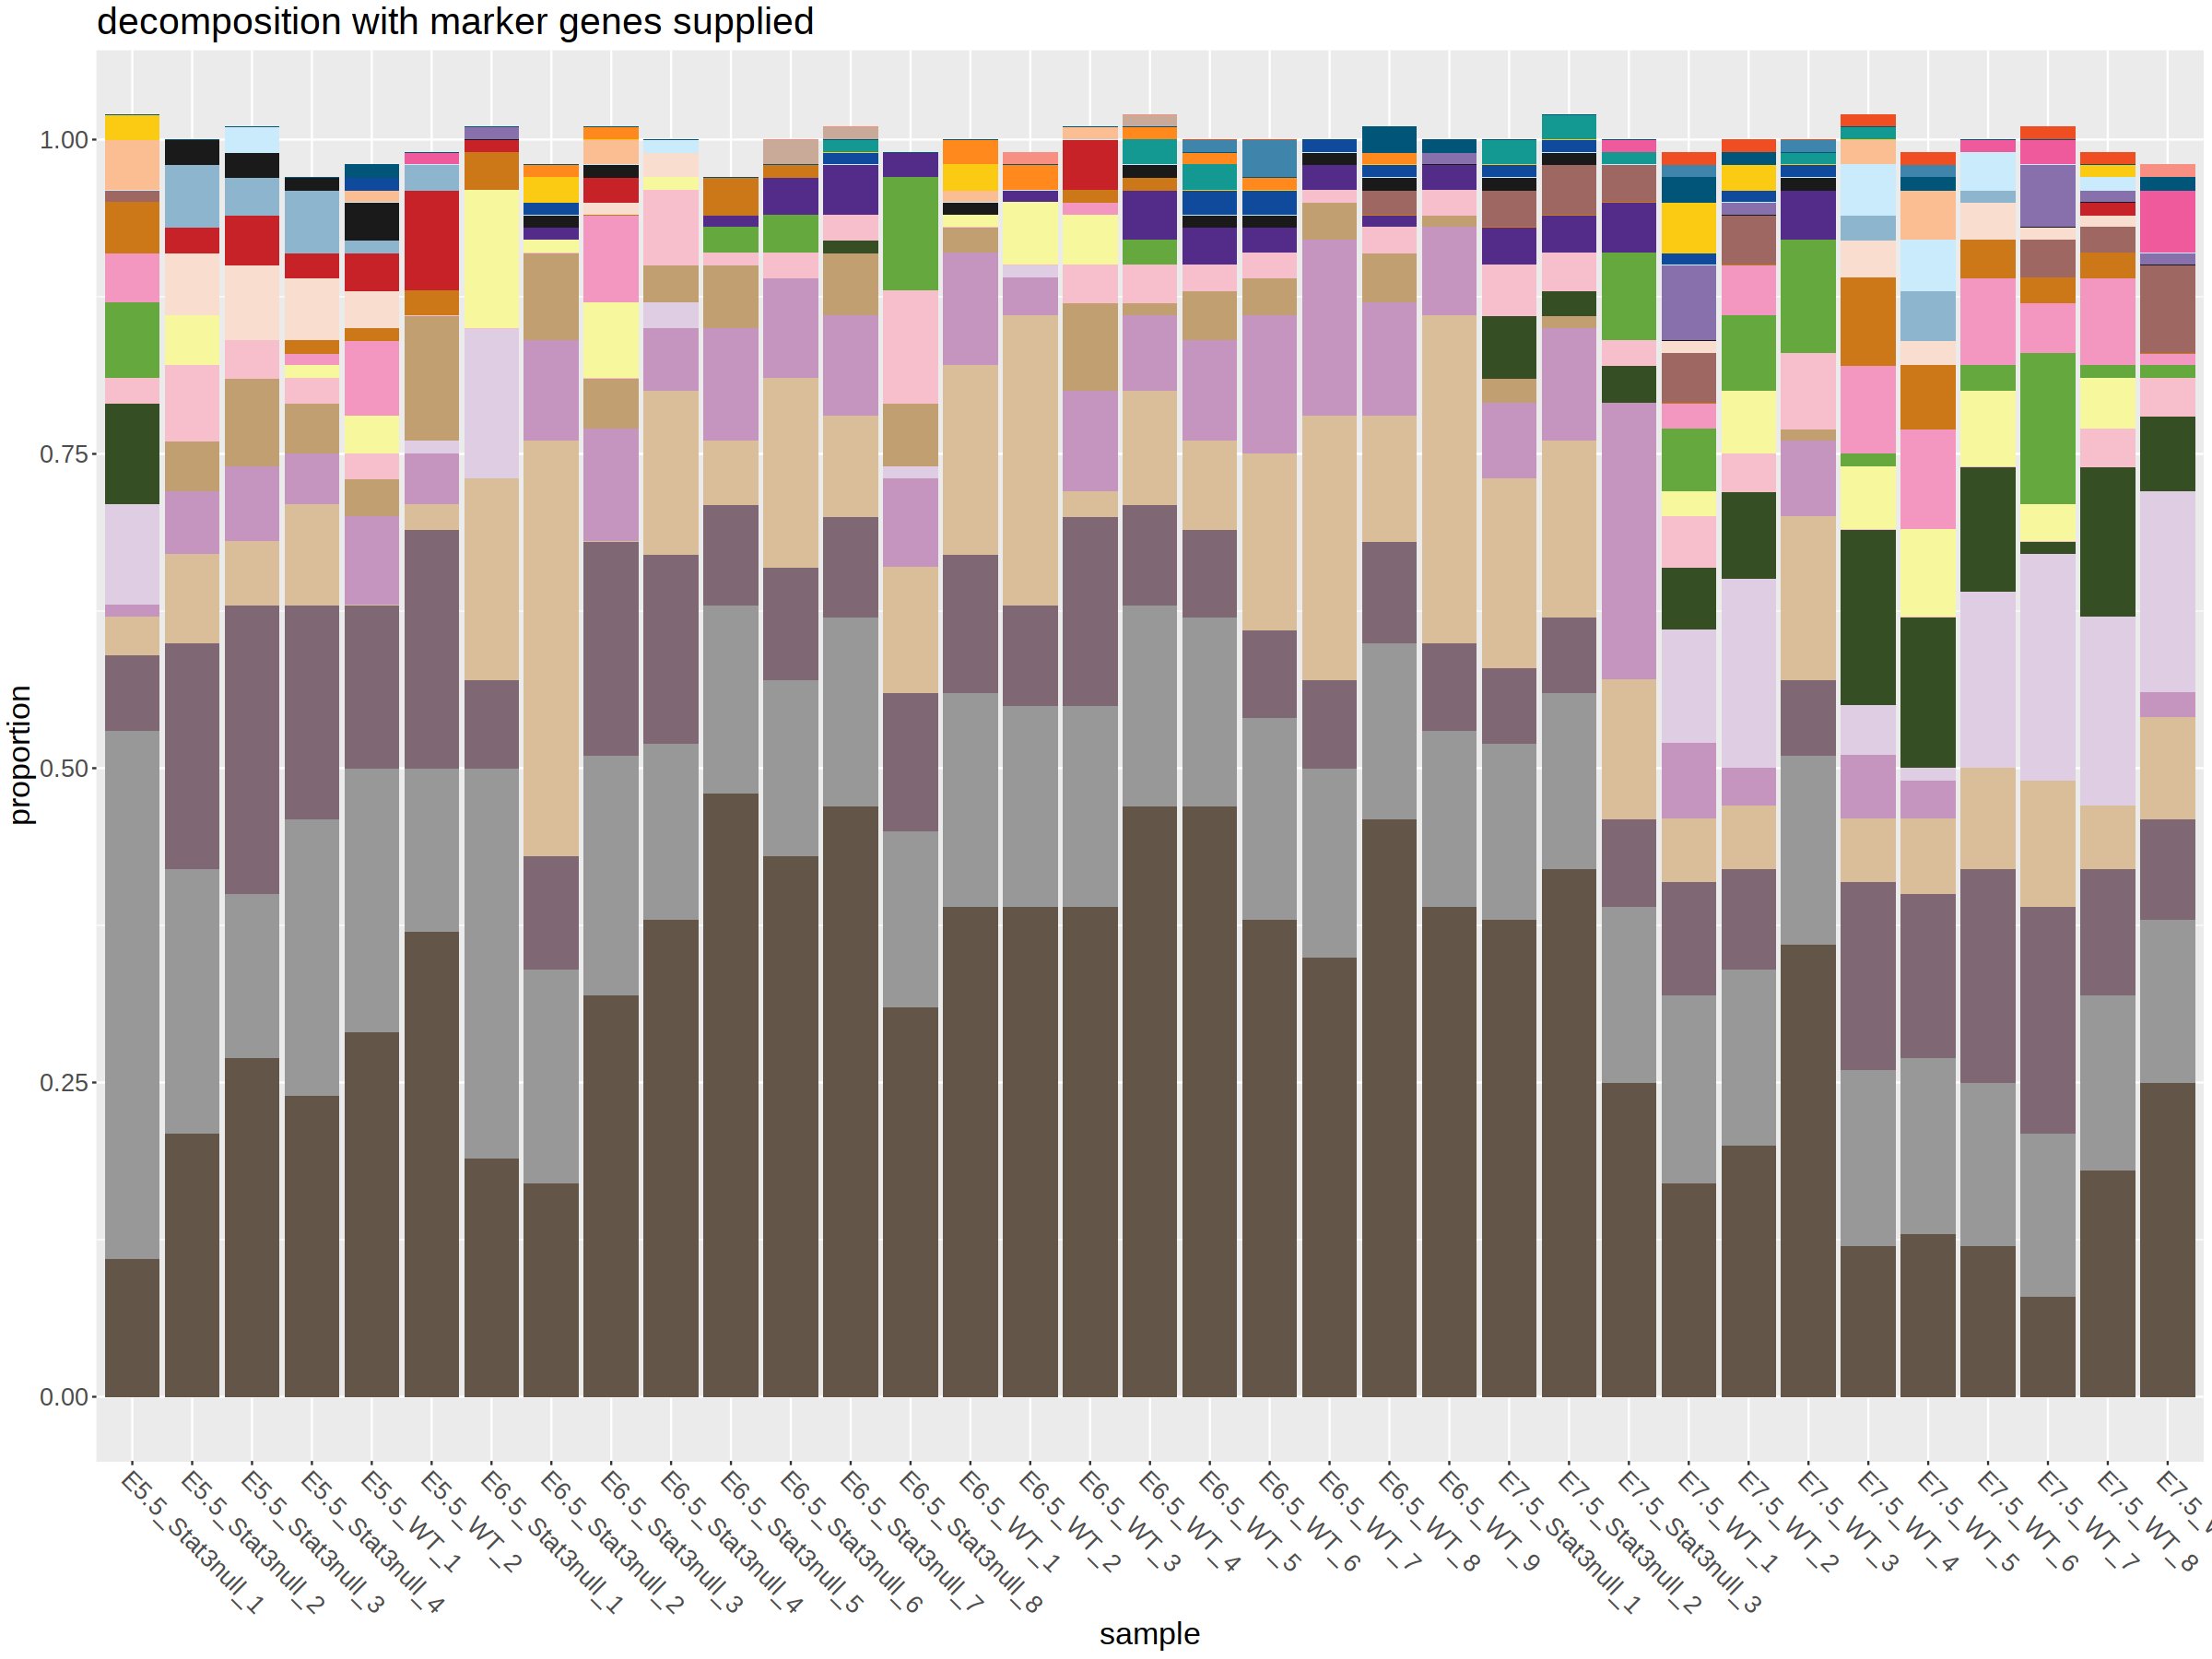

In [16]:
# W supplying markers
markers = fread("/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/results/rna/differential/cells/celltype/marker_genes/marker_genes_filtered.txt.gz")
markers = unique(markers$gene)

res <- BisqueRNA::ReferenceBasedDecomposition(bulk.eset, sc.eset, markers=markers, use.overlap=FALSE)

proportions = as.data.table(round(res$bulk.props,2), keep.rownames=T) %>% 
    setnames('rn', 'celltype') %>%
    melt(id.vars = 'celltype', variable.name = "sample", value.name = 'proportion')

ct_levels = proportions[, mean:=mean(proportion), by='celltype'] %>% unique(by='celltype') %>% .[order(mean), celltype]
proportions$celltype = factor(proportions$celltype, levels=ct_levels)
# options(repr.plot.width=20, repr.plot.height=80) 
# ggplot(proportions, aes(celltype, proportion, fill=celltype)) + 
#     geom_bar(stat='identity') + 
#     scale_fill_manual(values=celltype_colours) + 
#     facet_wrap(~sample, scales='free', ncol=2) + 
#     theme_bw() + 
#     theme(axis.text.x=element_text(angle=-45, hjust=0, vjust=1),
#           text=element_text(size=20, color='black'),
#           legend.position='none')
options(repr.plot.width=15, repr.plot.height=10) 

ggplot(proportions, aes(sample, proportion, fill=celltype)) + geom_bar(stat='identity') +  
    scale_fill_manual(values=celltype_colours) + 
    theme(axis.text.x=element_text(angle=-45, hjust=0, vjust=1),
          text=element_text(size=20, color='black'),
          legend.position='none') +
    ggtitle('decomposition with marker genes supplied')

In [37]:
unique(proportions$celltype)

[1] Allantois                      Anterior Primitive Streak     
 [3] Blood progenitors 1            Blood progenitors 2           
 [5] Caudal epiblast                Caudal Mesoderm               
 [7] Caudal neurectoderm            Def. endoderm                 
 [9] Endothelium                    Epiblast                      
[11] Erythroid1                     Erythroid2                    
[13] Erythroid3                     ExE ectoderm                  
[15] ExE endoderm                   ExE mesoderm                  
[17] Gut                            Haematoendothelial progenitors
[19] Intermediate mesoderm          Mesenchyme                    
[21] Mixed mesoderm                 Nascent mesoderm              
[23] Notochord                      Paraxial mesoderm             
[25] Parietal endoderm              PGC                           
[27] Pharyngeal mesoderm            Primitive Streak              
[29] Rostral neurectoderm           Somitic mesoderm              
[31] Surface ectoderm               Visceral endoderm             
32 Levels: Erythroid2 Blood progenitors 2 Erythroid3 ... Epiblast

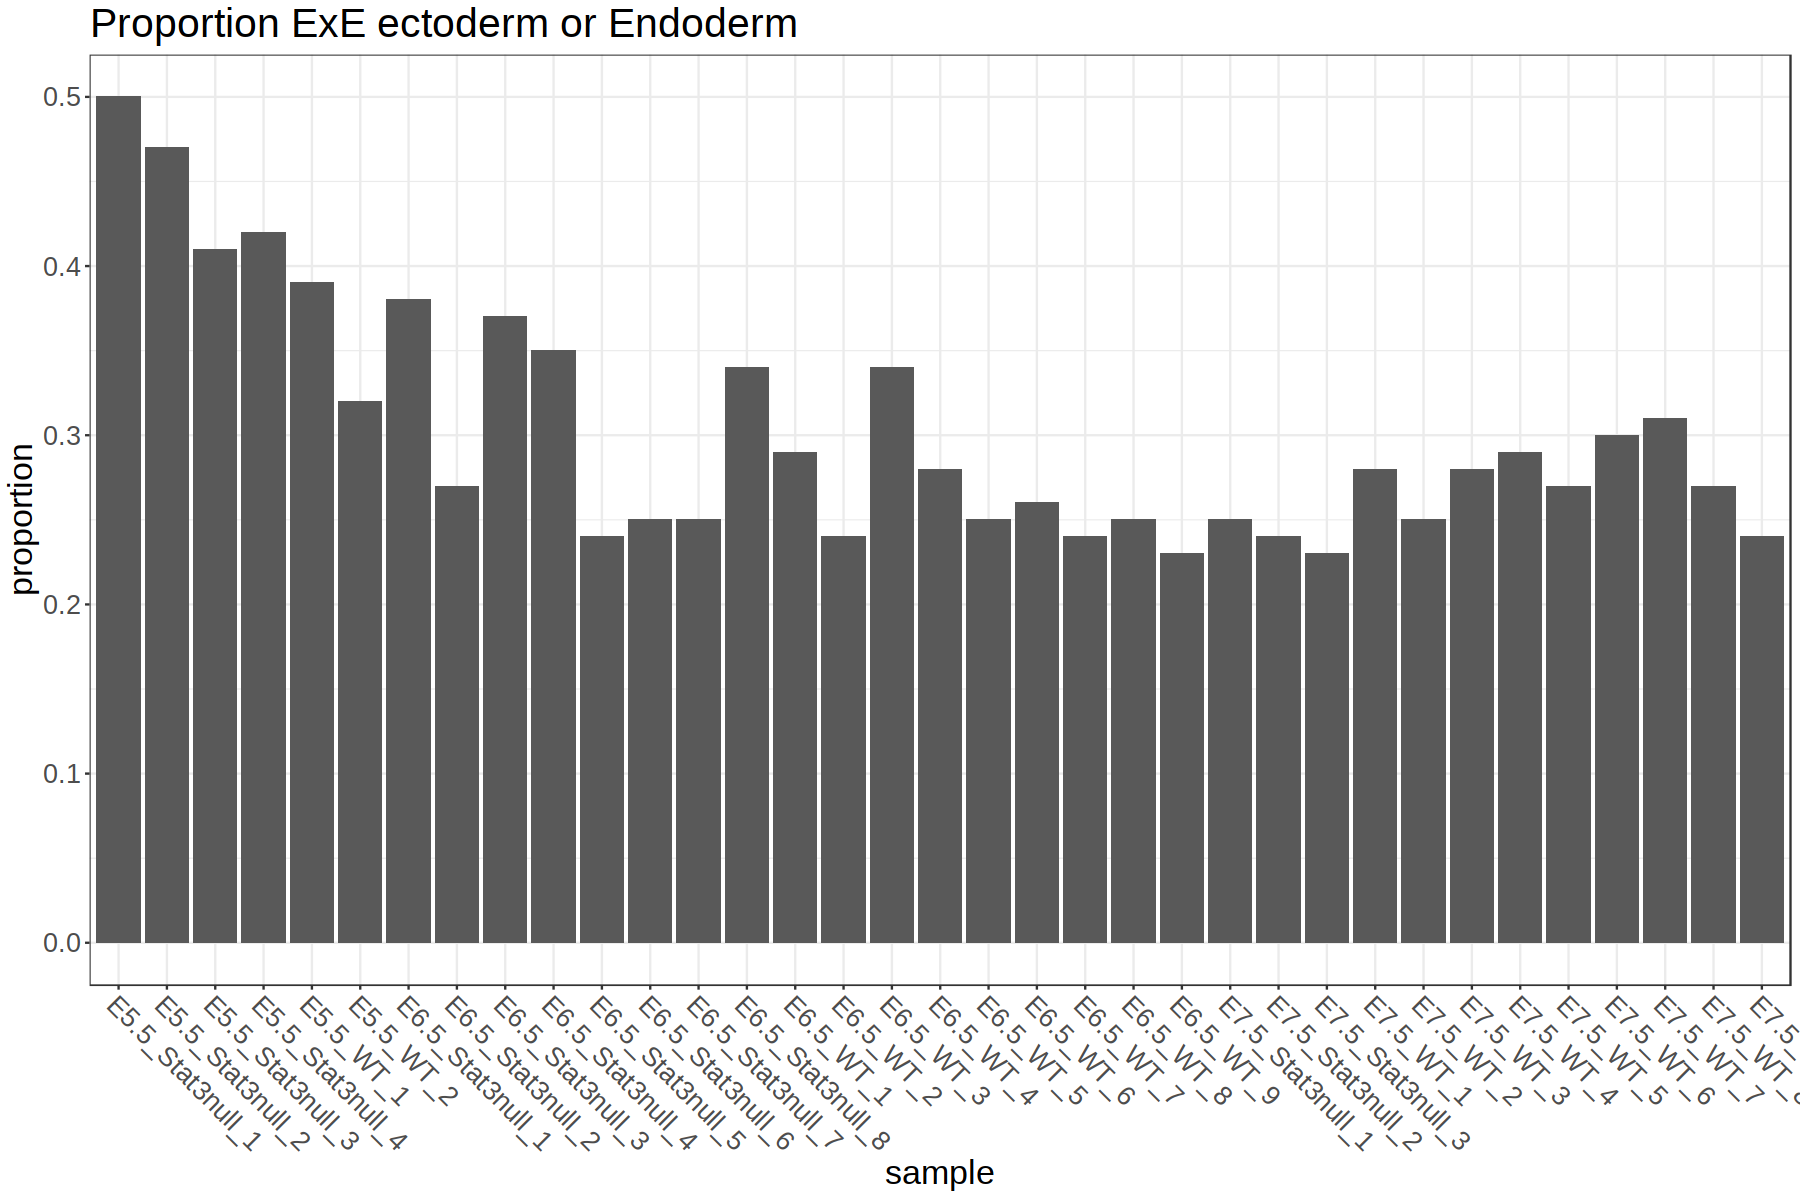

In [41]:
ExE = proportions[celltype %in% c("Visceral endoderm","ExE endoderm","ExE ectoderm","Parietal endoderm")] %>%
    .[,sum:=sum(proportion), by='sample'] %>%
    unique(by=c('sample', 'sum'))

options(repr.plot.width=15, repr.plot.height=10) 

ggplot(ExE, aes(sample, sum)) + geom_bar(stat='identity') + 
    theme_bw() + 
    theme(axis.text.x=element_text(angle=-45, hjust=0, vjust=1),
          text=element_text(size=20, color='black'),
          legend.position='none') +
    ylab('proportion') +
    ggtitle('Proportion ExE ectoderm or Endoderm') 

In [26]:
head(ExE)

celltype,sample,proportion,mean,sum
<fct>,<fct>,<dbl>,<dbl>,<dbl>
ExE ectoderm,E5.5_Stat3null_1,0.42,0.1648571,0.48
ExE ectoderm,E5.5_Stat3null_2,0.21,0.1648571,0.39
ExE ectoderm,E5.5_Stat3null_3,0.13,0.1648571,0.36
ExE ectoderm,E5.5_Stat3null_4,0.22,0.1648571,0.39
ExE ectoderm,E5.5_WT_1,0.21,0.1648571,0.34
ExE ectoderm,E5.5_WT_2,0.13,0.1648571,0.32


Decomposing into 32 cell types.

Using 15600 genes in both bulk and single-cell expression.

Converting single-cell counts to CPM and filtering zero variance genes.

Filtered 17 zero variance genes.

Converting bulk counts to CPM and filtering unexpressed genes.

Filtered 222 unexpressed genes.

Generating single-cell based reference from 44839 cells.


Inferring bulk transformation from single-cell alone.

Applying transformation to bulk samples and decomposing.



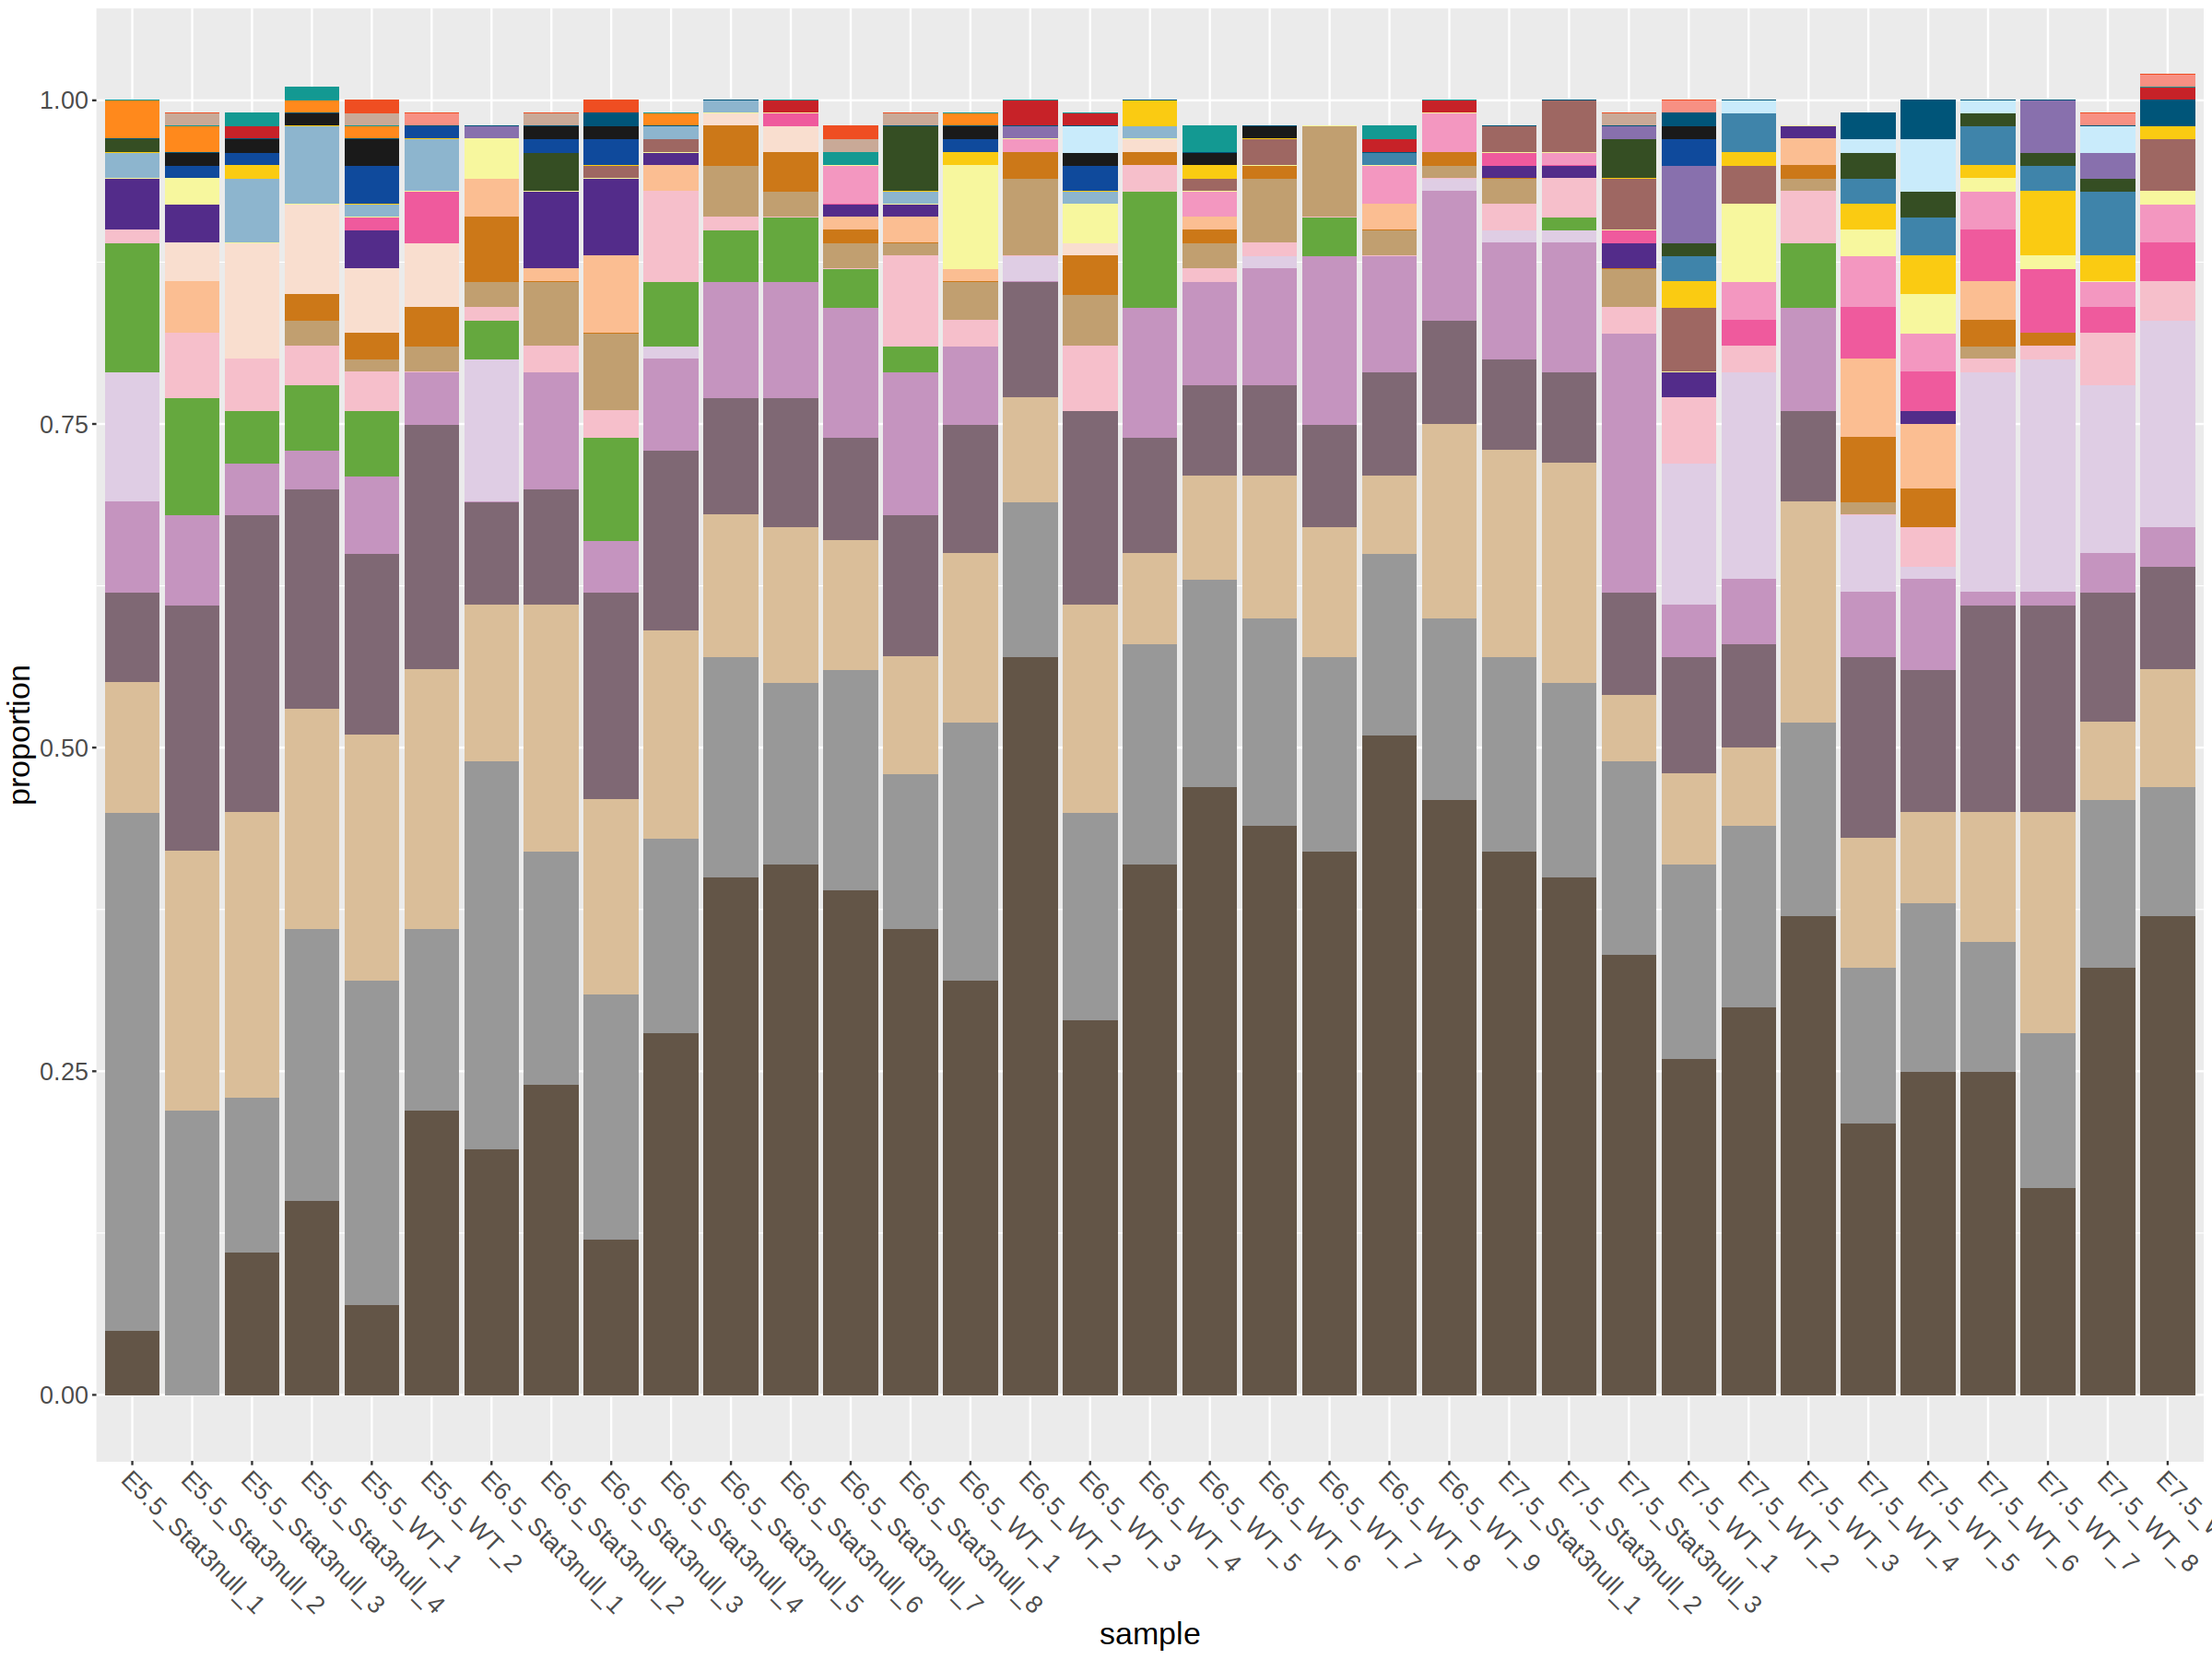

In [9]:
# W/O supplying marker genes
res <- BisqueRNA::ReferenceBasedDecomposition(bulk.eset, sc.eset, markers=NULL, use.overlap=FALSE)

proportions = as.data.table(round(res$bulk.props,2), keep.rownames=T) %>% 
    setnames('rn', 'celltype') %>%
    melt(id.vars = 'celltype', variable.name = "sample", value.name = 'proportion')

ct_levels = proportions[, mean:=mean(proportion), by='celltype'] %>% unique(by='celltype') %>% .[order(mean), celltype]
proportions$celltype = factor(proportions$celltype, levels=ct_levels)
# options(repr.plot.width=20, repr.plot.height=80) 
# ggplot(proportions, aes(celltype, proportion, fill=celltype)) + 
#     geom_bar(stat='identity') + 
#     scale_fill_manual(values=celltype_colours) + 
#     facet_wrap(~sample, scales='free', ncol=2) + 
#     theme_bw() + 
#     theme(axis.text.x=element_text(angle=-45, hjust=0, vjust=1),
#           text=element_text(size=20, color='black'),
#           legend.position='none')
options(repr.plot.width=20, repr.plot.height=15) 

ggplot(proportions, aes(sample, proportion, fill=celltype)) + geom_bar(stat='identity') +  
scale_fill_manual(values=celltype_colours) + 

    theme(axis.text.x=element_text(angle=-45, hjust=0, vjust=1),
          text=element_text(size=20, color='black'),
          legend.position='none') +
    ggtitle('decomposition without marker genes supplied')

In [10]:
# Lower resolution celltype annotation
unique(seurat@meta.data$celltype)

[1] "Epiblast"                       "Primitive Streak"              
 [3] "ExE ectoderm"                   "Visceral endoderm"             
 [5] "ExE endoderm"                   "Nascent mesoderm"              
 [7] "Rostral neurectoderm"           "Blood progenitors 2"           
 [9] "Mixed mesoderm"                 "ExE mesoderm"                  
[11] "Intermediate mesoderm"          "Pharyngeal mesoderm"           
[13] "Caudal epiblast"                "PGC"                           
[15] "Mesenchyme"                     "Haematoendothelial progenitors"
[17] "Blood progenitors 1"            "Surface ectoderm"              
[19] "Gut"                            "Paraxial mesoderm"             
[21] "Caudal neurectoderm"            "Notochord"                     
[23] "Somitic mesoderm"               "Caudal Mesoderm"               
[25] "Erythroid1"                     "Def. endoderm"                 
[27] "Parietal endoderm"              "Allantois"                     
[29] "Anterior Primitive Streak"      "Endothelium"                   
[31] "Erythroid3"                     "Erythroid2"

In [13]:
broad_celltypes = c('Epiblast' = 'Epiblast_prim_streak',  
'Primitive Streak' = 'Epiblast_prim_streak',  
'ExE ectoderm' = 'ExE ectoderm',  
'Visceral endoderm' = 'ExE endoderm',  
'ExE endoderm' = 'ExE endoderm',  
'Nascent mesoderm' = 'early mesoderm',  
'Rostral neurectoderm' = 'ectoderm',  
'Blood progenitors 2' = 'late mesoderm',  
'Mixed mesoderm' = 'early mesoderm',  
'ExE mesoderm' = 'early mesoderm',  
'Intermediate mesoderm' = 'early mesoderm',  
'Pharyngeal mesoderm' = 'early mesoderm',  
'Caudal epiblast' = 'Epiblast_prim_streak',  
'PGC' = 'PGC',  
'Mesenchyme' = 'late mesoderm',  
'Haematoendothelial progenitors' = 'late mesoderm',  
'Blood progenitors 1' = 'late mesoderm',  
'Surface ectoderm' = 'ectoderm',  
'Gut' = 'endoderm',  
'Paraxial mesoderm' = 'late mesoderm',  
'Caudal neurectoderm' = 'ectoderm',  
'Notochord' = 'early mesoderm',  
'Somitic mesoderm' = 'late mesoderm',  
'Caudal Mesoderm' = 'late mesoderm',  
'Erythroid1' = 'late mesoderm',  
'Def. endoderm' = 'endoderm',  
'Parietal endoderm' = 'endoderm',  
'Allantois' = 'late mesoderm',  
'Anterior Primitive Streak' = 'Epiblast_prim_streak',  
'Endothelium' = 'late mesoderm',  
'Forebrain/Midbrain/Hindbrain' = 'ectoderm',  
'Spinal cord' = 'ectoderm',  
'Cardiomyocytes' = 'late mesoderm',  
'Erythroid2' = 'late mesoderm',  
'NMP' = 'NMP',  
'Erythroid3' = 'late mesoderm')

In [15]:
seurat@meta.data$broad_celltype = stringr::str_replace_all(seurat@meta.data$celltype,broad_celltypes)

In [16]:
# Prepare Bisque object type
sample.ids <- colnames(seurat)
# individual.ids and cell.types should be in the same order as in sample.ids
sc.pheno <- data.frame(check.names=F, check.rows=F,
                       stringsAsFactors=F,
                       row.names=sample.ids,
                       SubjectName=seurat@meta.data$sample,
                       cellType=seurat@meta.data$broad_celltype)
sc.meta <- data.frame(labelDescription=c("SubjectName",
                                         "cellType"),
                      row.names=c("SubjectName",
                                  "cellType"))
sc.pdata <- new("AnnotatedDataFrame",
                 data=sc.pheno,
                 varMetadata=sc.meta)

sc.counts.matrix = as.matrix(seurat@assays$RNA@counts)

sc.eset <- Biobase::ExpressionSet(assayData=sc.counts.matrix,
                                  phenoData=sc.pdata)

In [ ]:
# W/O supplying marker genes
res <- BisqueRNA::ReferenceBasedDecomposition(bulk.eset, sc.eset, markers=NULL, use.overlap=FALSE)

proportions = as.data.table(round(res$bulk.props,2), keep.rownames=T) %>% 
    setnames('rn', 'celltype') %>%
    melt(id.vars = 'celltype', variable.name = "sample", value.name = 'proportion')

options(repr.plot.width=20, repr.plot.height=80) 
ggplot(proportions, aes(celltype, proportion, fill=celltype)) + 
    geom_bar(stat='identity') + 
    scale_fill_manual(values=celltype_colours) + 
    facet_wrap(~sample, scales='free', ncol=2) + 
    theme_bw() + 
    theme(axis.text.x=element_text(angle=-45, hjust=0, vjust=1),
          text=element_text(size=20, color='black'),
          legend.position='none')

Decomposing into 9 cell types.

Using 15600 genes in both bulk and single-cell expression.

Converting single-cell counts to CPM and filtering zero variance genes.

